# Ridge and Lasso Regression with Synthetic Data

Main idea: Ridge and Lasso are extensions of linear regression. They are useful when you have many predictors, correlated predictors, or a model that may overfit.

- Ridge regression adds a penalty on large coefficients, and improves stability when predictors are correlated
- Lasso regression adds a penalty on the absolute size of coefficients, and improves interpretability by performing feature selection.

Both methods help reduce overfitting compared with ordinary linear regression.

### Ridge and Lasso Regression with Synthetic Data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Generate synthetic data

In [2]:
np.random.seed(42)

n = 200

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = 0.8 * X1 + np.random.normal(0, 0.5, n)   # correlated with X1
X4 = 0.7 * X2 + np.random.normal(0, 0.5, n)   # correlated with X2
X5 = np.random.normal(0, 1, n)
X6 = np.random.normal(0, 1, n)
X7 = np.random.normal(0, 1, n)
X8 = np.random.normal(0, 1, n)

noise = np.random.normal(0, 2, n)

y = (10 + 5 * X1 - 3 * X2 + 2 * X5 + noise)

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "X4": X4,
    "X5": X5,
    "X6": X6,
    "X7": X7,
    "X8": X8,
    "y": y
})

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,y
0,0.496714,0.357787,-0.399843,0.628945,0.938284,1.399355,0.125225,-1.046911,12.920983
1,-0.138264,0.560785,-0.410299,-0.068533,-0.516045,0.924634,-0.429406,0.536653,9.343988
2,0.647689,1.083051,0.520773,1.192939,0.096121,0.059630,0.122298,1.185704,8.889602
3,1.523030,1.053802,1.241914,1.415480,-0.462275,-0.646937,0.543298,0.718953,11.930809
4,-0.234153,-1.377669,-0.412355,-0.757651,-0.434496,0.698223,0.048860,0.996048,11.127762


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      200 non-null    float64
 1   X2      200 non-null    float64
 2   X3      200 non-null    float64
 3   X4      200 non-null    float64
 4   X5      200 non-null    float64
 5   X6      200 non-null    float64
 6   X7      200 non-null    float64
 7   X8      200 non-null    float64
 8   y       200 non-null    float64
dtypes: float64(9)
memory usage: 14.2 KB


In [4]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,y
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,-0.040771,0.085868,-0.075444,0.064591,0.128251,0.133633,0.005374,0.082630,10.022659
std,0.931004,0.987004,0.838097,0.815968,0.955933,1.030322,0.986200,1.034967,5.742058
min,-2.619745,-3.241267,-2.257787,-2.285264,-2.423879,-2.896255,-2.591042,-2.921350,-3.455924
25%,-0.705128,-0.605838,-0.758110,-0.459445,-0.530901,-0.504126,-0.670177,-0.604105,6.294475
50%,-0.004192,0.078839,-0.070875,0.100887,0.130537,0.197755,-0.001512,0.076567,9.569386
75%,0.500852,0.687231,0.451458,0.630558,0.718316,0.873466,0.560991,0.740968,14.384222
max,2.720169,3.852731,2.748012,3.444934,2.526932,2.439752,2.579709,2.601683,26.161728


### Separate features and target

In [5]:
X = df.drop(columns="y")
y = df["y"]

### Train test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 160
Test rows: 40


### Define an evaluation function

In [7]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

### Ordinary Linear Regression

In [8]:
linear_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_results = evaluate_model("Linear Regression", y_test, linear_pred)

linear_results

{'Model': 'Linear Regression',
 'MAE': np.float64(1.6477896823890839),
 'RMSE': np.float64(2.211546357887769),
 'R2': 0.8533257626344868}

#### Why scaling matters

Ridge and Lasso penalize coefficient size. Therefore, features should be on the same scale before applying regularization.

### Ridge Regression

Ridge uses the L2 penalty. It shrinks coefficients but usually does not make them exactly zero.

In [9]:
ridge_alphas = np.logspace(-3, 3, 100)

ridge_model = Pipeline(
    steps=[("scaler", StandardScaler()), ("model", RidgeCV(alphas=ridge_alphas, cv=5))]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_results = evaluate_model("Ridge Regression", y_test, ridge_pred)

ridge_results

{'Model': 'Ridge Regression',
 'MAE': np.float64(1.6382072216368768),
 'RMSE': np.float64(2.204693738915069),
 'R2': 0.854233313561917}

In [10]:
# Check the best alpha selected by cross validation
best_ridge_alpha = ridge_model.named_steps["model"].alpha_

print(f"Best Ridge alpha: {best_ridge_alpha:.4f}")

Best Ridge alpha: 2.1544


### Lasso Regression

Lasso uses the L1 penalty. It can shrink some coefficients exactly to zero, which makes it useful for feature selection.

In [11]:
lasso_alphas = np.logspace(-3, 3, 100)

lasso_model = Pipeline(
    steps=[("scaler", StandardScaler()), 
           ("model", LassoCV(alphas=lasso_alphas, cv=5, max_iter=10000, random_state=42))]
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_results = evaluate_model("Lasso Regression", y_test, lasso_pred)

lasso_results

{'Model': 'Lasso Regression',
 'MAE': np.float64(1.6755260820097841),
 'RMSE': np.float64(2.1905820515094345),
 'R2': 0.8560933730013705}

In [12]:
# Check the best alpha selected by cross validation
best_lasso_alpha = lasso_model.named_steps["model"].alpha_

print(f"Best Lasso alpha: {best_lasso_alpha:.4f}")

Best Lasso alpha: 0.0756


### Compare model performance

In [13]:
results = pd.DataFrame([
    linear_results,
    ridge_results,
    lasso_results
])

results

,Model,MAE,RMSE,R2
0,Linear Regression,1.647790,2.211546,0.853326
1,Ridge Regression,1.638207,2.204694,0.854233
2,Lasso Regression,1.675526,2.190582,0.856093


Linear regression is the baseline.

Ridge may improve performance when predictors are correlated.

Lasso may improve interpretability by shrinking weak predictors to zero.

### Compare coefficients

In [14]:
feature_names = X.columns

linear_coefs = linear_model.named_steps["model"].coef_
ridge_coefs = ridge_model.named_steps["model"].coef_
lasso_coefs = lasso_model.named_steps["model"].coef_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Linear Regression": linear_coefs,
    "Ridge Regression": ridge_coefs,
    "Lasso Regression": lasso_coefs
})

coef_table

,Feature,Linear Regression,Ridge Regression,Lasso Regression
0,X1,4.426821,4.249976,4.340511
1,X2,-2.737576,-2.652247,-2.653532
2,X3,0.004240,0.149181,0.000000
3,X4,-0.000087,-0.059388,-0.000000
4,X5,1.896315,1.879378,1.827917
5,X6,0.124334,0.127539,0.039565
6,X7,-0.109372,-0.114888,-0.018781
7,X8,-0.283511,-0.275033,-0.197759


### Identify features selected by Lasso

In [15]:
selected_features = coef_table.loc[
    coef_table["Lasso Regression"] != 0,
    ["Feature", "Lasso Regression"]
]

selected_features

,Feature,Lasso Regression
0,X1,4.340511
1,X2,-2.653532
4,X5,1.827917
5,X6,0.039565
6,X7,-0.018781
7,X8,-0.197759


Lasso keeps features with nonzero coefficients.

Features with coefficients equal to zero are treated as less useful for prediction.

### Visualize coefficients

<Figure size 1000x600 with 0 Axes>

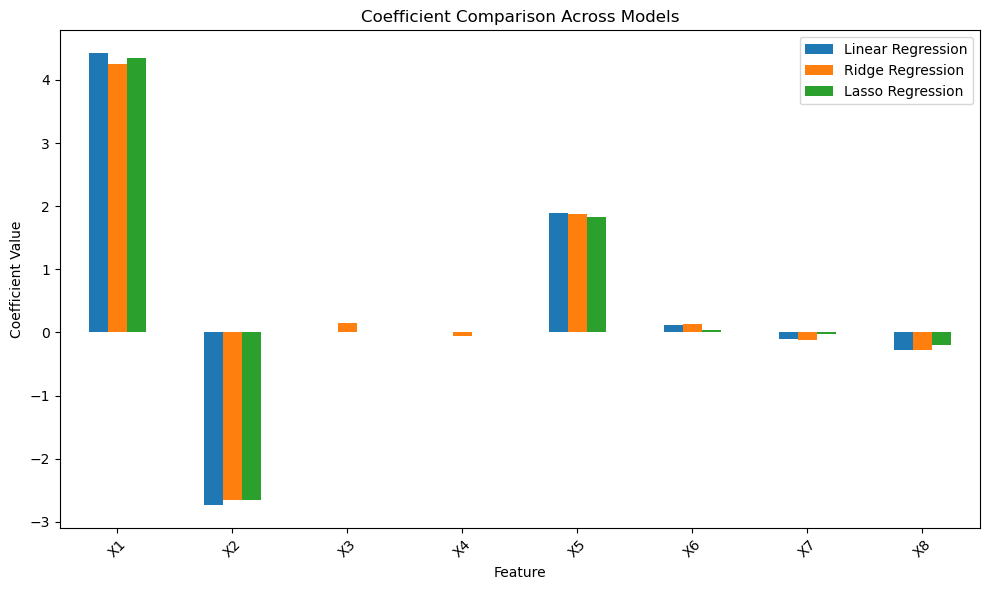

In [16]:
coef_table_plot = coef_table.set_index("Feature")

plt.figure(figsize=(10, 6))
coef_table_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Coefficient Comparison Across Models")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Actual vs predicted values

In [17]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Prediction": linear_pred,
    "Ridge Prediction": ridge_pred,
    "Lasso Prediction": lasso_pred
})

prediction_comparison.head(10)

,Actual,Linear Prediction,Ridge Prediction,Lasso Prediction
0,9.936432,6.142143,6.264429,6.336209
1,8.326749,2.084848,2.109933,2.497699
2,7.463131,6.777548,6.783889,6.868614
3,7.439418,4.771750,4.934018,4.776295
4,12.491520,12.370450,12.414481,12.156903
5,11.821702,12.428865,12.448305,12.220063
6,11.496056,10.688634,10.607138,10.747503
7,5.822311,6.169488,6.208003,6.238128
8,2.546599,4.118251,4.239501,4.555767
9,9.245799,9.256704,9.354199,9.022598


### Plot actual vs predicted for the best model

In [18]:
# Let us use the model with the highest test R²
best_model_name = results.sort_values("R2", ascending=False).iloc[0]["Model"]

print(f"Best model based on R2: {best_model_name}")

Best model based on R2: Lasso Regression


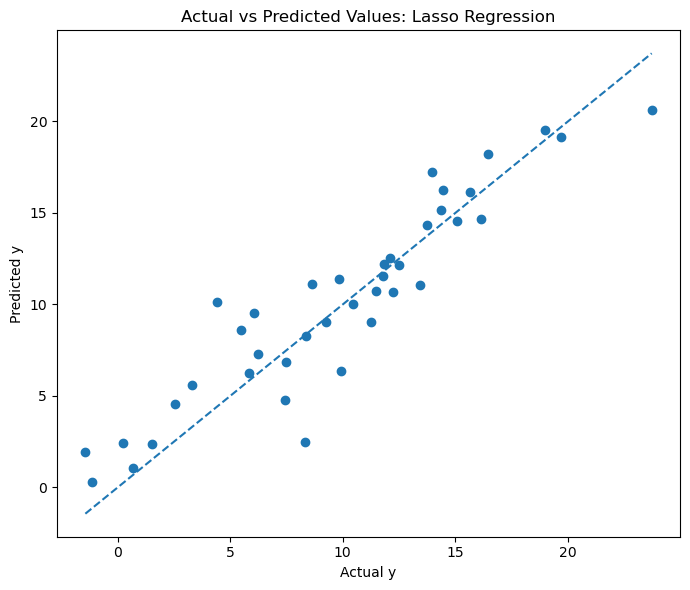

In [19]:
if best_model_name == "Linear Regression":
    best_pred = linear_pred
elif best_model_name == "Ridge Regression":
    best_pred = ridge_pred
else:
    best_pred = lasso_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title(f"Actual vs Predicted Values: {best_model_name}")
plt.tight_layout()
plt.show()

### Make a single prediction

In [20]:
new_observation = pd.DataFrame({
    "X1": [1.2],
    "X2": [-0.7],
    "X3": [0.9],
    "X4": [-0.4],
    "X5": [1.5],
    "X6": [0.2],
    "X7": [-1.0],
    "X8": [0.5]
})

ridge_single_prediction = ridge_model.predict(new_observation)
lasso_single_prediction = lasso_model.predict(new_observation)

print(f"Ridge prediction: {ridge_single_prediction[0]:.3f}")
print(f"Lasso prediction: {lasso_single_prediction[0]:.3f}")

Ridge prediction: 20.859
Lasso prediction: 20.620


### Save figures

<Figure size 1000x600 with 0 Axes>

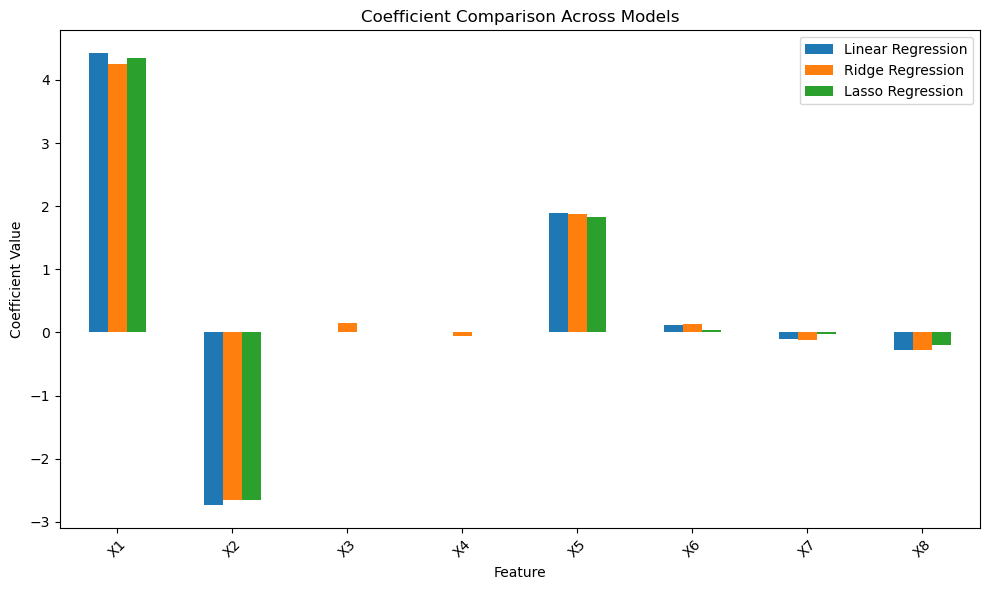

In [21]:
os.makedirs("../../reports/figures", exist_ok=True)

coef_table_plot = coef_table.set_index("Feature")

plt.figure(figsize=(10, 6))
coef_table_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Coefficient Comparison Across Models")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../reports/figures/ridge_lasso_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

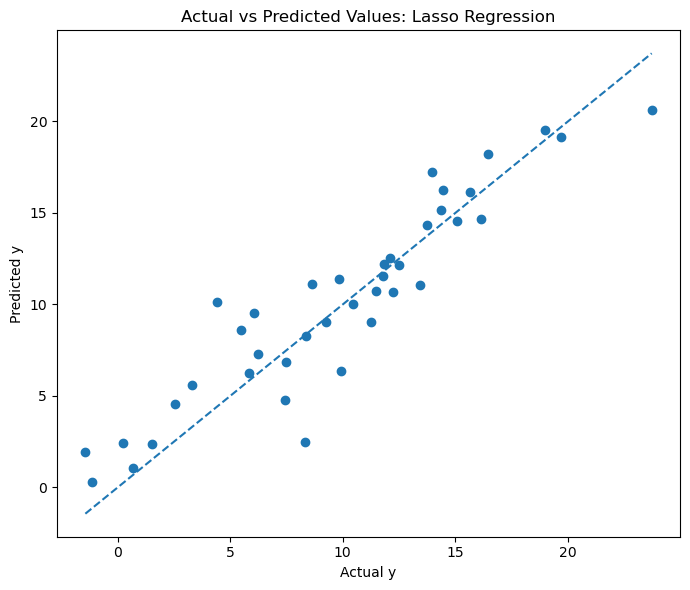

In [22]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title(f"Actual vs Predicted Values: {best_model_name}")
plt.tight_layout()
plt.savefig("../../reports/figures/ridge_lasso_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()